#  Cargar todos los archivos CSV que se encuentran en la carpeta GuardarDatos. Luego los uniremos en una sola tabla.

Este notebook realiza las siguientes tareas:

Carga los archivos CSV de la carpeta Db.

Une todos los archivos en un solo DataFrame.

Verifica y muestra los duplicados basados en el tweet_id.

Elimina los duplicados.

Reemplaza el tweet_id por un índice numérico único.

Guarda los datos procesados en un nuevo archivo CSV.

# Codigo Depurado

✅ Archivo cargado: comentarios_imss.csv
✅ Archivo cargado: comentarios_imss_.csv
✅ Archivo cargado: comentarios_imss_4.csv
✅ Archivo cargado: comentarios_imss_urls_.csv
✅ Archivo cargado: comentarios_imss_urls_1.csv
✅ Archivo cargado: comentarios_imss_urls_2.csv
✅ Archivo cargado: comentarios_imss_urls_3.csv
✅ Archivo cargado: comentarios_imss_urls_4.csv
✅ Archivo cargado: comentarios_imss_urls_5.csv
✅ Archivo cargado: comentarios_imss_urls_6.csv
✅ Archivo cargado: comentarios_imss_urls_7.csv
✅ Archivo cargado: comentarios_imss_urls_8.csv
✅ Archivo cargado: comentarios_imss_urls_9.csv
✅ Archivo cargado: comentarios_limpios.csv
✅ Archivo cargado: comentarios_limpios_modi.csv
✅ Archivo cargado: tweets_clasificados.csv
✅ Archivo cargado: tweets_clasificados2.csv
✅ Archivo cargado: tweets_clasificados_completo_robusto_33333.csv
✅ Archivo cargado: tweets_clasificados_final.csv
✅ Archivo cargado: tweets_clasificados_mejorado.csv
✅ Archivo cargado: tweets_limpios.csv
✅ Archivo cargado: tweets

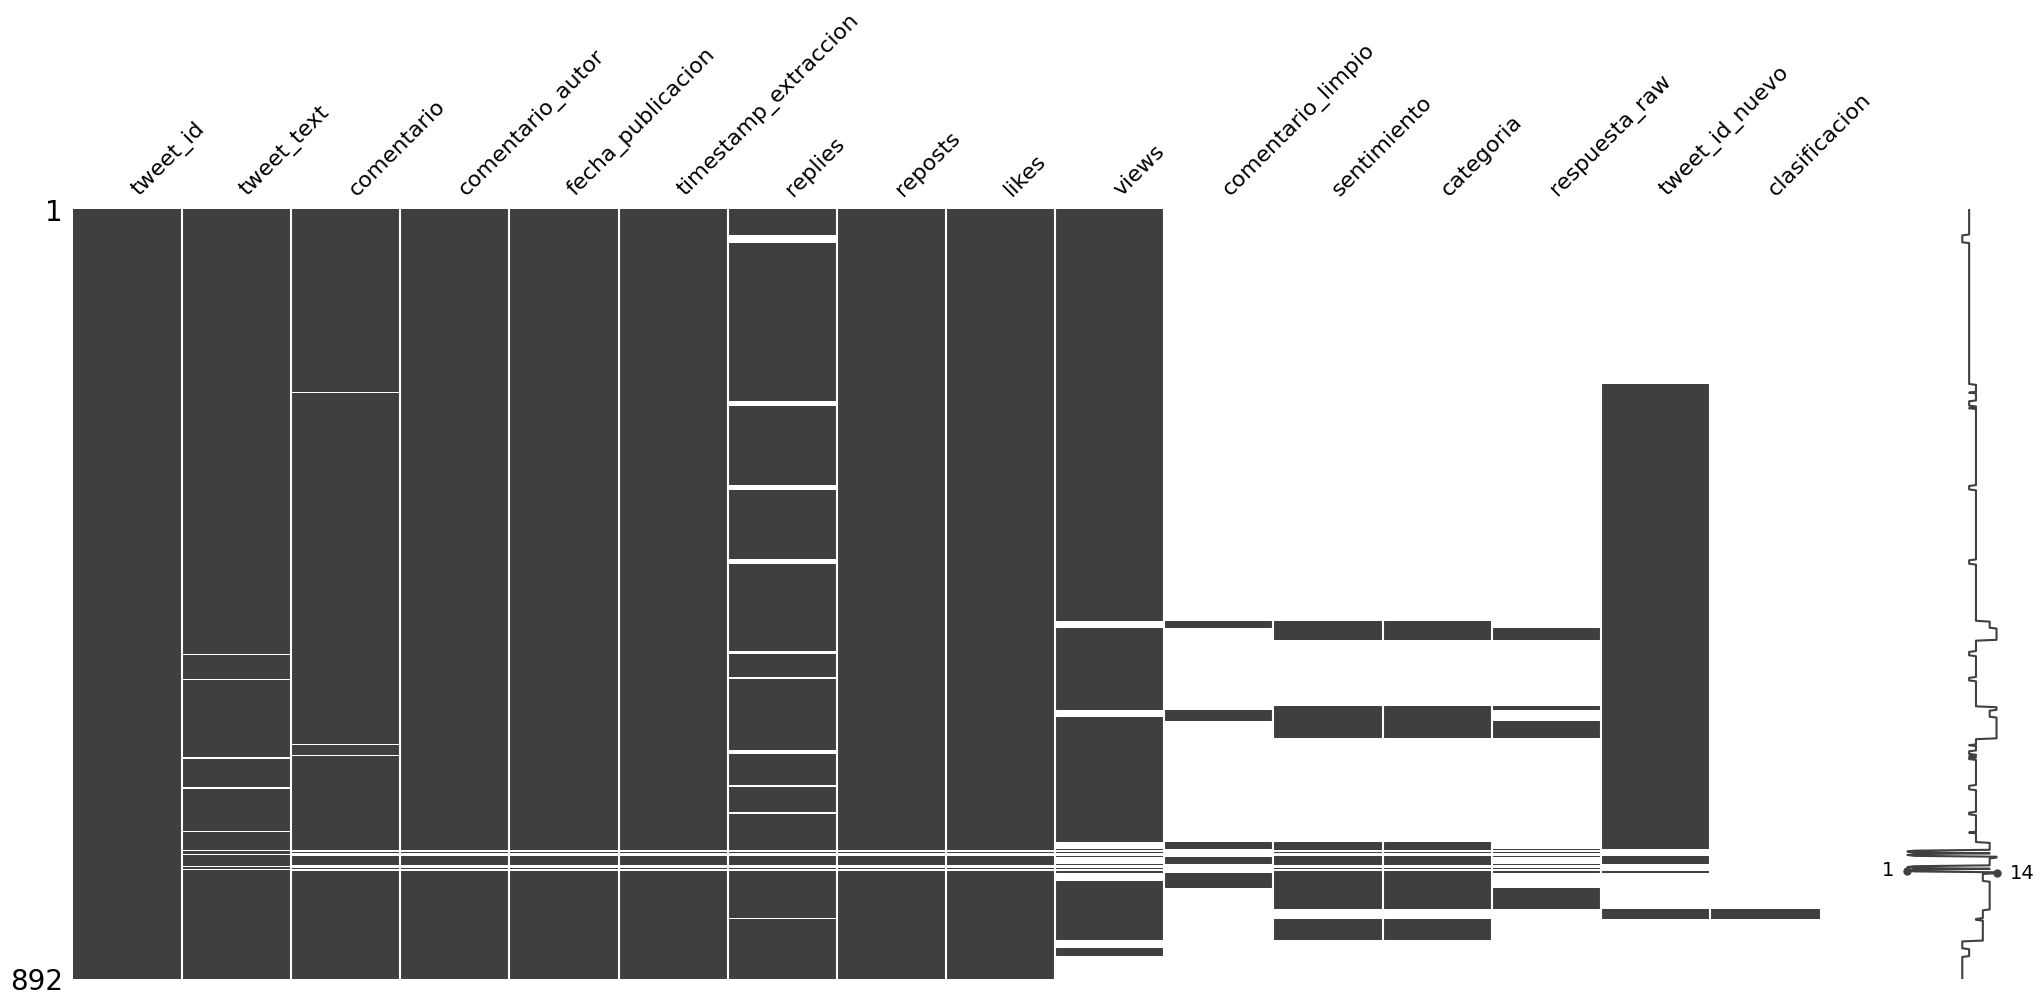

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tweet_id              892 non-null    object 
 1   tweet_text            880 non-null    object 
 2   comentario            876 non-null    object 
 3   comentario_autor      880 non-null    object 
 4   fecha_publicacion     880 non-null    object 
 5   timestamp_extraccion  880 non-null    object 
 6   replies               837 non-null    float64
 7   reposts               880 non-null    float64
 8   likes                 880 non-null    float64
 9   views                 803 non-null    object 
 10  comentario_limpio     55 non-null     object 
 11  sentimiento           149 non-null    object 
 12  categoria             149 non-null    object 
 13  respuesta_raw         70 non-null     object 
 14  tweet_id_nuevo        562 non-null    float64
 15  clasificacion         1

In [2]:
# --- Importar librerías necesarias ---
import os
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import unicodedata

# --- Ruta de la carpeta donde están los CSV ---
folder_path = '../db/'

# --- Función para cargar y concatenar CSVs con manejo de errores y delimitadores ---
def cargar_datos_csv(carpeta):
    if not os.path.exists(carpeta):
        raise FileNotFoundError(f"❌ La carpeta '{carpeta}' no existe.")
        
    archivos_csv = [f for f in os.listdir(carpeta) if f.endswith('.csv')]
    if not archivos_csv:
        raise FileNotFoundError(f"❌ No se encontraron archivos CSV en la carpeta '{carpeta}'.")

    lista_df = []
    for archivo in archivos_csv:
        ruta = os.path.join(carpeta, archivo)
        try:
            df = pd.read_csv(ruta, sep=None, engine='python', on_bad_lines='skip')
            lista_df.append(df)
            print(f"✅ Archivo cargado: {archivo}")
        except Exception as e:
            print(f"❌ Error al leer '{archivo}': {e}")

    if not lista_df:
        raise ValueError("❌ No se pudo cargar ningún archivo CSV correctamente.")
    
    return pd.concat(lista_df, ignore_index=True)

# --- Función para limpiar texto ---
def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)  # Eliminar URLs
    texto = re.sub(r'[^a-zA-Záéíóúüñ0-9\s]', '', texto)  # Quitar símbolos
    texto = re.sub(r'\s+', ' ', texto).strip()           # Quitar espacios extras
    texto = unicodedata.normalize('NFKD', texto)         # Normalizar acentos
    return texto

# --- Cargar los datos ---
df = cargar_datos_csv(folder_path)

# --- Visualización de valores nulos ---
print("\n📊 Visualización de valores nulos:")
msno.matrix(df)
plt.show()
df.info()

# --- Validar existencia de la columna 'comentario' ---
if 'comentario' not in df.columns:
    raise ValueError("❌ La columna 'comentario' no está presente en los archivos cargados.")

# --- LIMPIEZA DEL CAMPO 'comentario' ---
df = df.copy()

# 1. Eliminar comentarios nulos o vacíos
df = df.dropna(subset=['comentario'])
df = df[df['comentario'].str.strip() != '']

# 2. Eliminar comentarios duplicados
df = df.drop_duplicates(subset='comentario', keep='first')

# 3. Limpiar texto del comentario
df['comentario'] = df['comentario'].apply(limpiar_texto)

# 4. Generar ID único
df['tweet_id_nuevo'] = range(1, len(df) + 1)

# 5. Guardar archivo limpio
output_file = os.path.join(folder_path, 'comentarios_limpios.csv')
df.to_csv(output_file, index=False)

# 6. Validar limpieza
print("\n✅ Resumen final:")
print(f"- Comentarios nulos: {df['comentario'].isnull().sum()}")
print(f"- Comentarios vacíos: {(df['comentario'].str.strip() == '').sum()}")
print(f"- Total de comentarios únicos: {df.shape[0]}")
print(f"📁 Datos limpios guardados en: {output_file}")

# --- CORRECCIÓN DE COMILLAS EN EL CSV ---
with open(output_file, 'r', encoding='utf-8') as f:
    contenido = f.read()

# Reemplazar triple comillas dobles por comillas simples
contenido_corregido = contenido.replace('"""', "'")

# Guardar el archivo corregido
output_file_corr = os.path.join(folder_path, 'comentarios_limpios_reemplazado.csv')
with open(output_file_corr, 'w', encoding='utf-8') as f:
    f.write(contenido_corregido)

print(f"📁 Archivo corregido guardado como: {output_file_corr}")


# Limpieza de comentarios

Visualización de valores nulos:


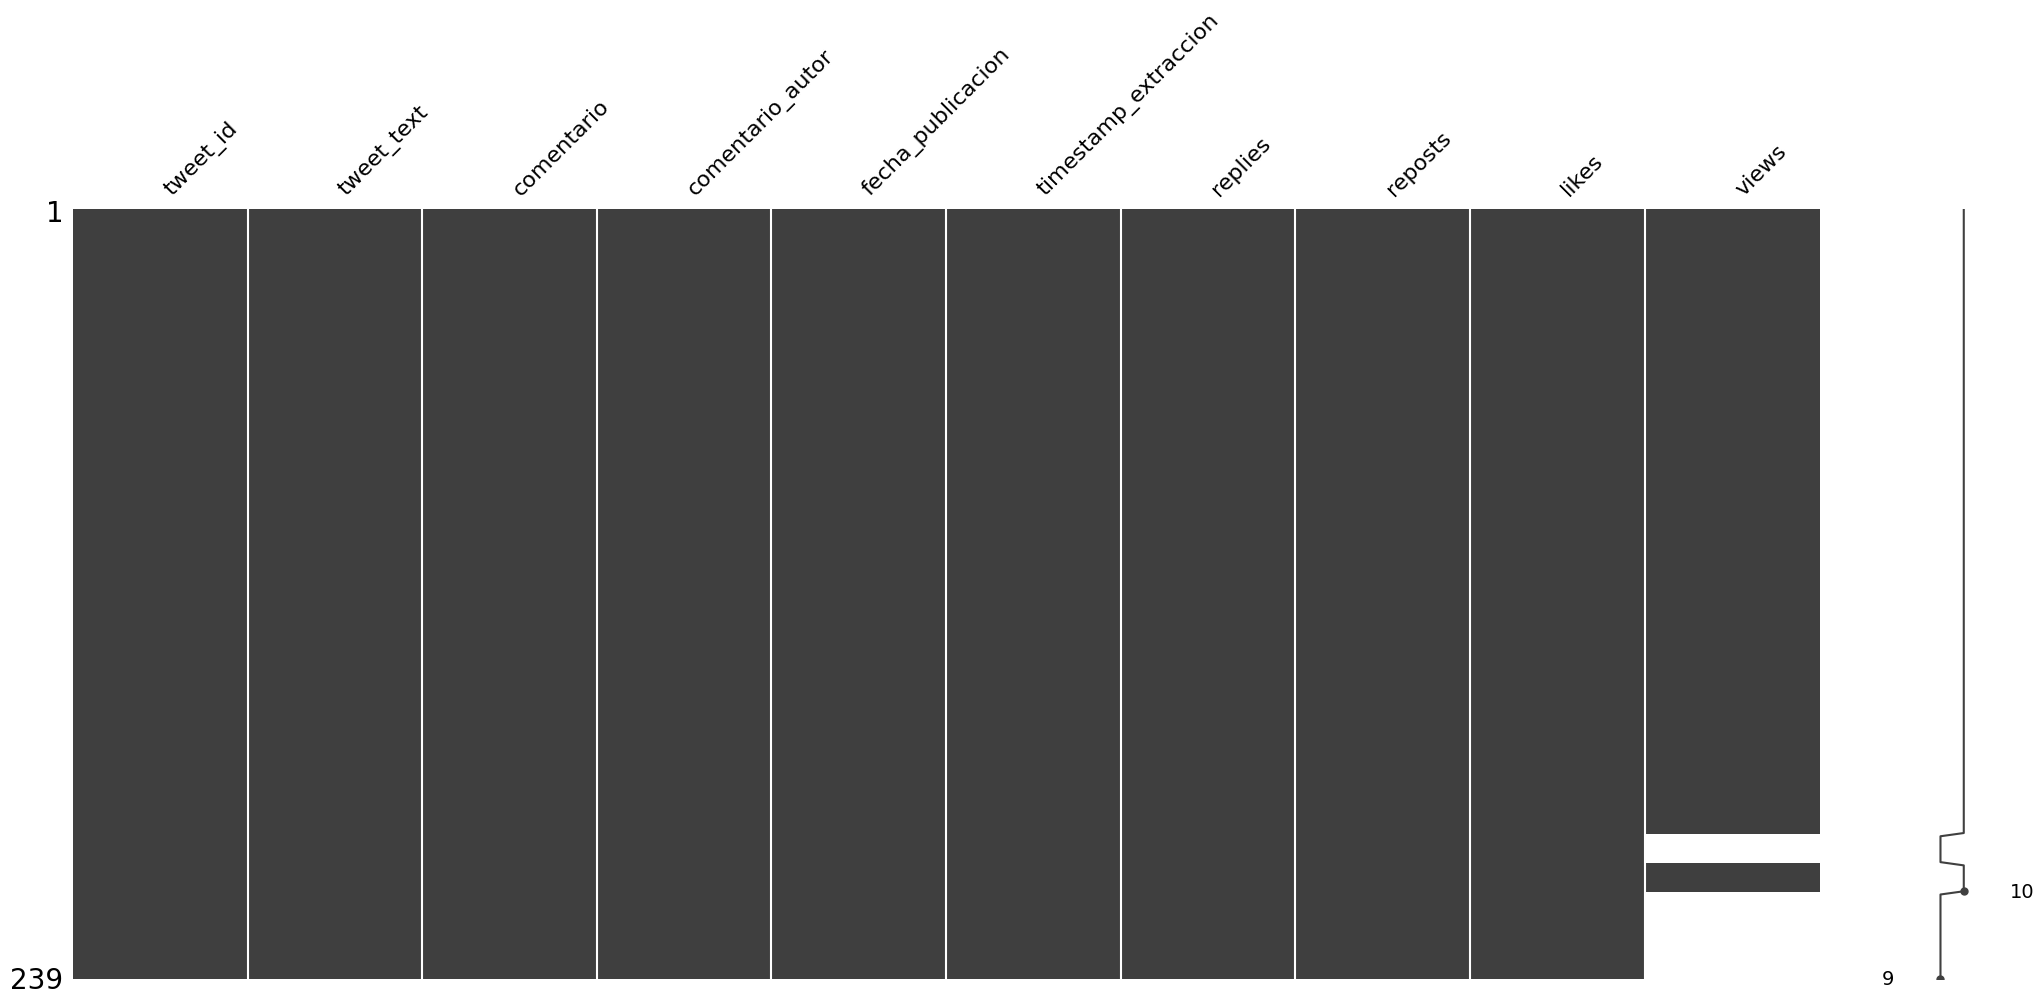

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tweet_id              239 non-null    object 
 1   tweet_text            239 non-null    object 
 2   comentario            239 non-null    object 
 3   comentario_autor      239 non-null    object 
 4   fecha_publicacion     239 non-null    object 
 5   timestamp_extraccion  239 non-null    object 
 6   replies               239 non-null    float64
 7   reposts               239 non-null    int64  
 8   likes                 239 non-null    int64  
 9   views                 203 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 18.8+ KB

📊 Resumen final:
- Comentarios nulos: 0
- Comentarios vacíos: 2
- Total de comentarios únicos: 106
✅ Datos limpios guardados en: ../db/../db/db_procesadas/comentarios_limpios.csv


In [6]:
# Importar librerías necesarias
import os
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import unicodedata

# Ruta de la carpeta donde están los CSV
folder_path = '../db/'

# Función para cargar y concatenar CSVs con manejo de errores y delimitadores
def cargar_datos_csv(carpeta):
    if not os.path.exists(carpeta):
        raise FileNotFoundError(f"La carpeta '{carpeta}' no existe.")
        
    archivos_csv = [f for f in os.listdir(carpeta) if f.endswith('.csv')]
    if not archivos_csv:
        raise FileNotFoundError(f"No se encontraron archivos CSV en la carpeta '{carpeta}'.")

    lista_df = []
    for archivo in archivos_csv:
        ruta = os.path.join(carpeta, archivo)
        try:
            df = pd.read_csv(ruta, sep=None, engine='python', on_bad_lines='skip')
            lista_df.append(df)
        except Exception as e:
            print(f"❌ Error al leer '{archivo}': {e}")

    if not lista_df:
        raise ValueError("No se pudo cargar ningún archivo CSV correctamente.")
    
    return pd.concat(lista_df, ignore_index=True)

# Función para limpiar texto
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)  # eliminar URLs
    texto = re.sub(r'[^a-zA-Záéíóúüñ0-9\s]', '', texto)  # quitar símbolos
    texto = re.sub(r'\s+', ' ', texto).strip()           # quitar espacios extras
    texto = unicodedata.normalize('NFKD', texto)         # normaliza acentos
    return texto

# Cargar los datos
df = cargar_datos_csv(folder_path)

# Visualizar nulos
print("Visualización de valores nulos:")
msno.matrix(df)
plt.show()
df.info()

# --- LIMPIEZA DEL CAMPO COMENTARIO ---
if 'comentario' not in df.columns:
    raise ValueError("La columna 'comentario' no está presente en los archivos cargados.")

# Asegurar copia y evitar advertencias
df = df.copy()

# 1. Eliminar filas con comentario nulo o vacío
df = df.dropna(subset=['comentario'])
df = df[df['comentario'].str.strip() != '']

# 2. Eliminar duplicados en comentario
df = df.drop_duplicates(subset='comentario', keep='first')

# 3. Limpiar texto del comentario
df['comentario'] = df['comentario'].apply(limpiar_texto)

# 4. Crear ID nuevo
df['tweet_id_nuevo'] = range(1, len(df) + 1)

# 5. Guardar archivo limpio
output_file = os.path.join(folder_path, '../db/db_procesadas/comentarios_limpios.csv')
df.to_csv(output_file, index=False)

# 6. Validar limpieza
print("\n📊 Resumen final:")
print(f"- Comentarios nulos: {df['comentario'].isnull().sum()}")
print(f"- Comentarios vacíos: {(df['comentario'].str.strip() == '').sum()}")
print(f"- Total de comentarios únicos: {df.shape[0]}")
print(f"✅ Datos limpios guardados en: {output_file}")


# Transformacion de las comillas

In [8]:
# Leer el archivo CSV como texto
with open('../db/db_procesadas/comentarios_limpios.csv', 'r', encoding='utf-8') as f:
    contenido = f.read()

# Reemplazar triple comillas dobles por comilla simple
contenido_corregido = contenido.replace('"""', "'")

# Guardar el resultado en un nuevo archivo
with open('../db/db_procesadas/comentarios_limpios_reemplazado.csv', 'w', encoding='utf-8') as f:
    f.write(contenido_corregido)

print("✅ Archivo corregido guardado como 'comentarios_limpios_reemplazado.csv'")



✅ Archivo corregido guardado como 'comentarios_limpios_reemplazado.csv'


# codigo sin comillas

Visualización de valores nulos:


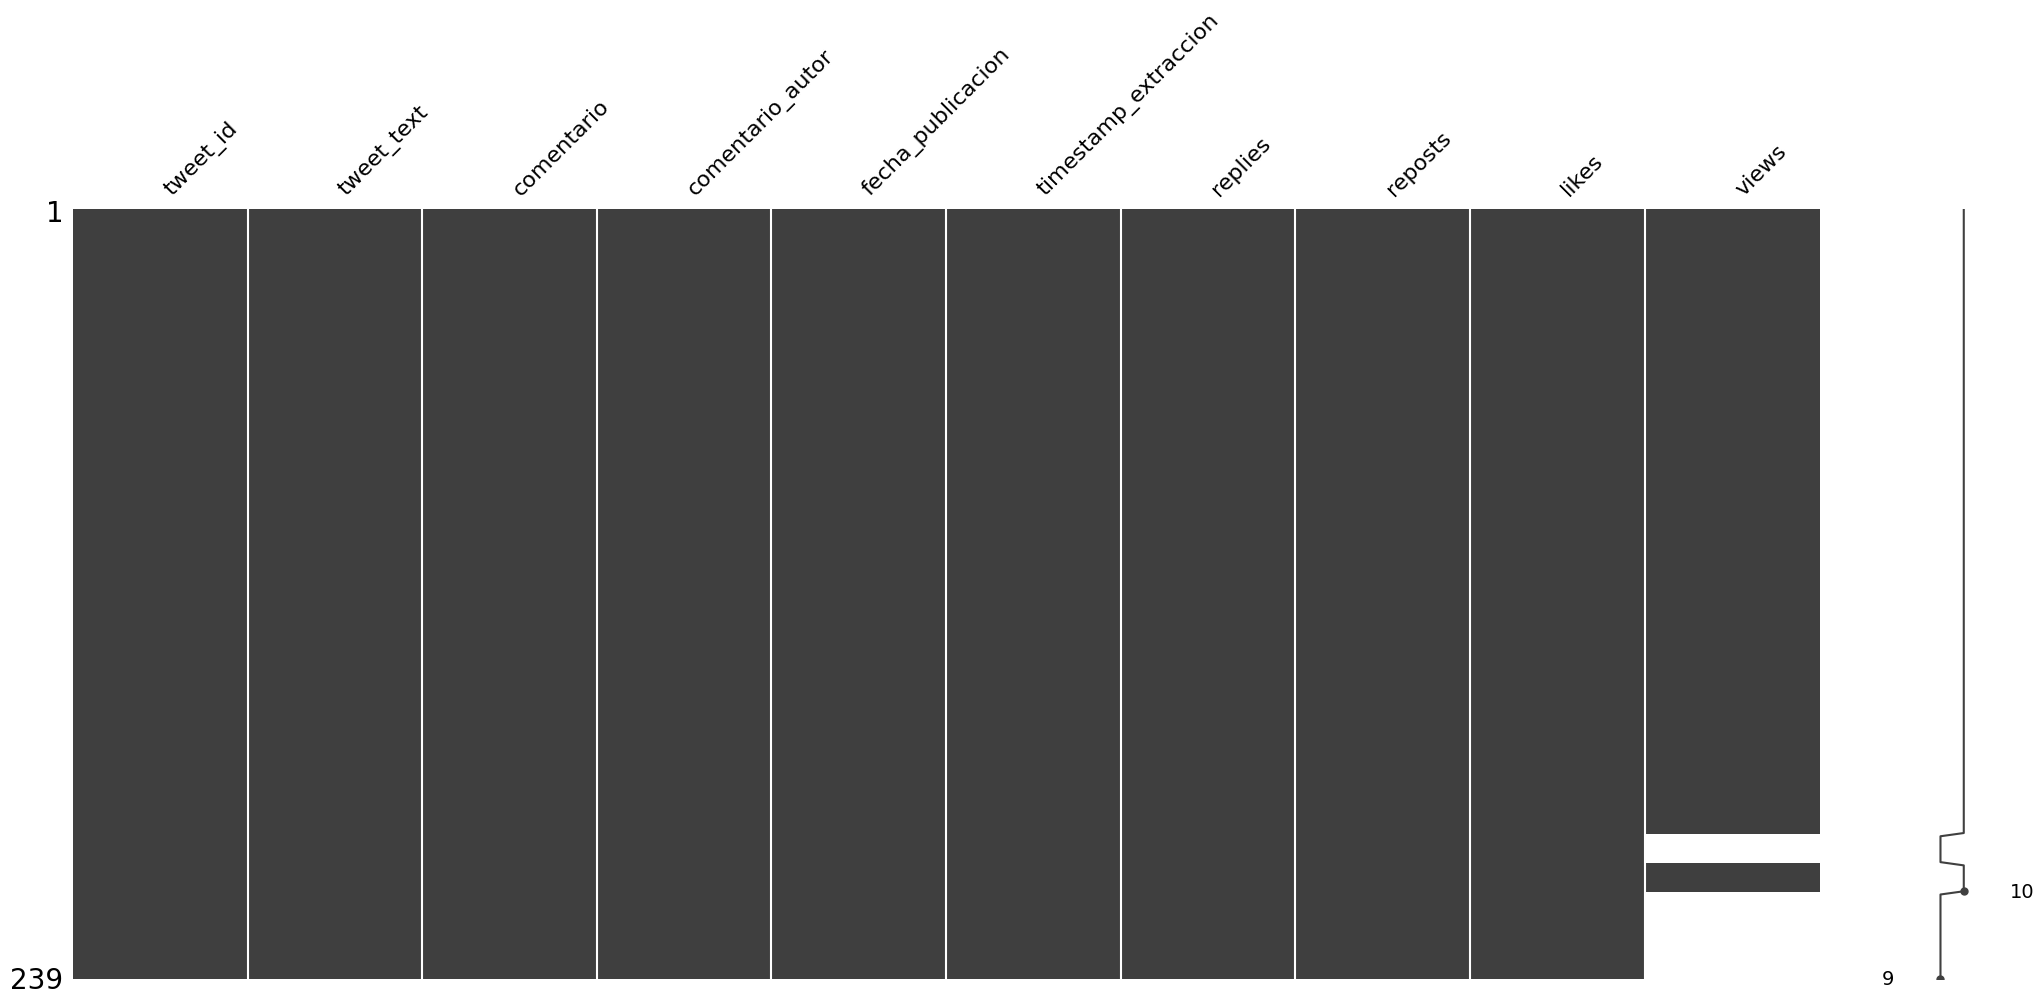

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tweet_id              239 non-null    object 
 1   tweet_text            239 non-null    object 
 2   comentario            239 non-null    object 
 3   comentario_autor      239 non-null    object 
 4   fecha_publicacion     239 non-null    object 
 5   timestamp_extraccion  239 non-null    object 
 6   replies               239 non-null    float64
 7   reposts               239 non-null    int64  
 8   likes                 239 non-null    int64  
 9   views                 203 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 18.8+ KB

✅ Datos limpios guardados en: ../db/../db/db_procesadas/comentarios_limpios_modi.csv
Comentarios nulos: 0
Comentarios vacíos: 2
Total de comentarios únicos: 106


In [9]:
# Importar librerías necesarias
import os
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import csv  # para evitar comillas en exportación

# Ruta de la carpeta donde están los CSV
folder_path = '../db/'

# Función para cargar y concatenar CSVs
def cargar_datos_csv(carpeta):
    archivos_csv = [f for f in os.listdir(carpeta) if f.endswith('.csv')]
    lista_df = []
    for archivo in archivos_csv:
        try:
            df_temp = pd.read_csv(os.path.join(carpeta, archivo), encoding='utf-8')
            lista_df.append(df_temp)
        except Exception as e:
            print(f"⚠️ Error al leer {archivo}: {e}")
    return pd.concat(lista_df, ignore_index=True)

# Función para limpiar texto
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)  # eliminar URLs
    texto = re.sub(r'[^a-zA-Záéíóúüñ0-9\s]', '', texto)  # quitar símbolos
    texto = re.sub(r'\s+', ' ', texto).strip()           # quitar espacios extras
    return texto

# Cargar los datos
df = cargar_datos_csv(folder_path)

# Validar existencia de columna 'comentario'
if 'comentario' not in df.columns:
    raise KeyError("❌ La columna 'comentario' no se encuentra en el DataFrame.")

# Visualización de valores nulos
print("Visualización de valores nulos:")
msno.matrix(df)
plt.show()
df.info()

# --- LIMPIEZA DEL CAMPO COMENTARIO ---
# 1. Eliminar filas con comentario nulo o vacío
df = df.dropna(subset=['comentario'])
df = df[df['comentario'].str.strip() != '']

# 2. Eliminar duplicados en comentario
df = df.drop_duplicates(subset='comentario', keep='first')

# 3. Limpiar texto del comentario
df.loc[:, 'comentario'] = df['comentario'].apply(limpiar_texto)

# 4. Limpiar comillas de campos de texto
columnas_a_limpiar = ['tweet_text', 'comentario_autor']
for col in columnas_a_limpiar:
    if col in df.columns:
        df[col] = df[col].astype(str)
        # Eliminar cualquier tipo de comillas
        df[col] = df[col].str.replace('"', '', regex=False)
        df[col] = df[col].str.replace("'", '', regex=False)
        df[col] = df[col].str.strip()

# 5. Crear ID nuevo
df['tweet_id_nuevo'] = range(1, len(df) + 1)

# 6. Guardar archivo limpio (sin comillas automáticas)
output_file = os.path.join(folder_path, '../db/db_procesadas/comentarios_limpios_modi.csv')
df.to_csv(output_file, index=False, encoding='utf-8', quoting=csv.QUOTE_NONE, escapechar=' ')

# 7. Validar limpieza
print("\n✅ Datos limpios guardados en:", output_file)
print("Comentarios nulos:", df['comentario'].isnull().sum())
print("Comentarios vacíos:", (df['comentario'].str.strip() == '').sum())
print("Total de comentarios únicos:", df.shape[0])

